In [1]:
import os

# Save the current PATH
original_path = os.environ['PATH']

# Set CUDA 12.5 environment variables, appending the original PATH explicitly
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.5'
os.environ['PATH'] = f"/usr/local/cuda-12.5/bin:{original_path}"
os.environ['LD_LIBRARY_PATH'] = f"/usr/local/cuda-12.5/lib64:{os.environ.get('LD_LIBRARY_PATH', '')}"

#!rm -rf /home/ids/yuhe/.cache/torch_extensions


CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/diffusion-AE/'
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()

print('Current working directory is:', '\n', notebook_path)

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code/diffusion-AE


In [2]:
%load_ext autoreload
%autoreload 2

In [2]:
from templates import *
from templates_cls import *
# from experiment_classifier import ClsModel
import matplotlib.pyplot as plt

In [3]:
def show_results_bg_t(model, batch_bg, batch_t, xt_bg, xt_t, latent_bg, latent_t):

    fig1, ax1 = plt.subplots(1, 2, figsize=(8, 5))
    fig2, ax2 = plt.subplots(1, 2, figsize=(8, 5))

    ori_bg = (batch_bg + 1) / 2
    ori_t = (batch_t + 1) / 2
    diff_img_bg = model.render(xt_bg, latent_bg, T=100)
    diff_img_t = model.render(xt_t, latent_t, T=100)

    ax1[0].imshow(ori_bg[0].permute(1, 2, 0).cpu())
    ax1[1].imshow(diff_img_bg[0].permute(1, 2, 0).cpu())
    ax2[0].imshow(ori_t[0].permute(1, 2, 0).cpu())
    ax2[1].imshow(diff_img_t[0].permute(1, 2, 0).cpu())
    
# print(conf.name)
def load_diffusion_encoder(conf, device):
    model = LitModel(conf)
    print(f'checkpoints/{conf.name}/last.ckpt')
    state = torch.load(f'checkpoints/{conf.name}/last.ckpt', map_location='cpu')
    model.load_state_dict(state['state_dict'], strict=False)

    return model, model.ema_model

import yaml
from argparse import Namespace
## our model:
from templates_mlp_latent_D import ffhq256_autoenc_mlp
from experiment_mlp_latent_D import MlpModel

def load_yaml_config(file_path):
    with open(file_path, "r") as file:
        config = yaml.safe_load(file)  # Load the YAML file safely
    return config
    
def load_cs_mlp(mlp_conf, result_path):
    mlp_model = MlpModel(mlp_conf)
    print(f'load weights from {result_path}')
    state_dict = torch.load(result_path,
                        map_location='cpu')
    print('latent step:', state_dict['global_step'])

    mlp_model.load_state_dict(state_dict['state_dict'], strict=False);
    # mlp_model.to(device)
    # Use the EMA model for evaluation
    # mlp_model.ema_mlp.eval()

    return mlp_model, mlp_model.ema_mlp

In [4]:
device = 'cuda:0'
encoder_conf = ffhq256_autoenc()
encoder, encoder_ema = load_diffusion_encoder(encoder_conf, device)
encoder.eval()
encoder.to(device)
encoder_ema.eval()
encoder_ema.to(device)

Seed set to 0


Model params: 160.69 M
checkpoints/ffhq256_autoenc/last.ckpt


BeatGANsAutoencModel(
  (time_embed): TimeStyleSeperateEmbed(
    (time_embed): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): SiLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
    )
    (style): Identity()
  )
  (input_blocks): ModuleList(
    (0): TimestepEmbedSequential(
      (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1-2): 2 x TimestepEmbedSequential(
      (0): ResBlock(
        (in_layers): Sequential(
          (0): GroupNorm32(32, 128, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (h_upd): Identity()
        (x_upd): Identity()
        (emb_layers): Sequential(
          (0): SiLU()
          (1): Linear(in_features=512, out_features=256, bias=True)
        )
        (cond_emb_layers): Sequential(
          (0): SiLU()
          (1): Linear(in_features=512, out_features=128, bias

In [ ]:

# mlp_conf = Namespace(**load_yaml_config("./results/baseline/znorm_lr1e-2/logs/version_0/hparams.yaml"))
result_path = "./results/baseline/no_znorm/mlp-epoch=499.ckpt" 

load_conf = ffhq256_autoenc_mlp()
mlp_model, mlp_model_ema = load_cs_mlp(load_conf, result_path)
mlp_model.eval()
# mlp_model.to(device)
# mlp_model_ema.eval()
# mlp_model_ema.to(device)




Seed set to 0
Seed set to 0


Model params: 160.69 M
loading pretrain ... 130M
step: 1563562
loading latent stats ...
Loaded pretrained model from checkpoints/ffhq256_autoenc/last.ckpt' successfully.
loading latent stats ...
load weights from ./results/baseline/no_znorm/mlp-epoch=499.ckpt


FileNotFoundError: [Errno 2] No such file or directory: './results/baseline/no_znorm/mlp-epoch=499.ckpt'

In [9]:
print(mlp_model.conds_mean)



None


## 1. Load and show original images

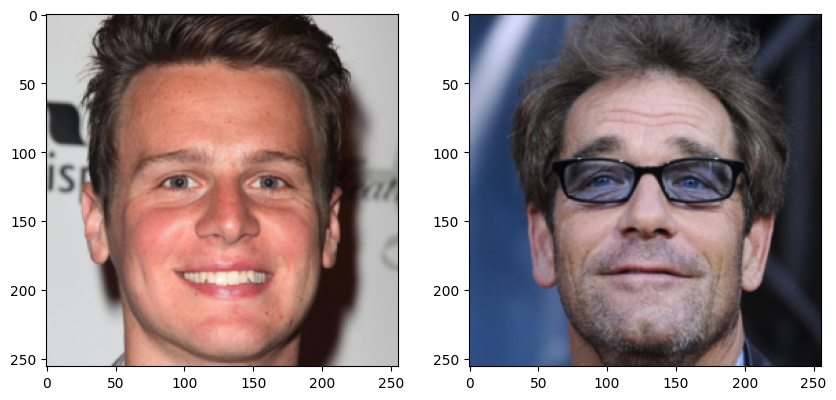

In [7]:
data = ImageDataset('notebooks/bg_glasses', image_size=load_conf.img_size, exts=['jpg', 'JPG', 'png'], do_augment=False)
batch_bg = data[1]['img'][None]
batch_t = data[0]['img'][None]

# torch.manual_seed(1)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
img_bg = (batch_bg+1)/2
img_t = (batch_t+1)/2
ax[0].imshow(img_bg[0].permute(1, 2, 0).cpu())
ax[1].imshow(img_t[0].permute(1, 2, 0).cpu())

## Reconstruction by diffusion AE

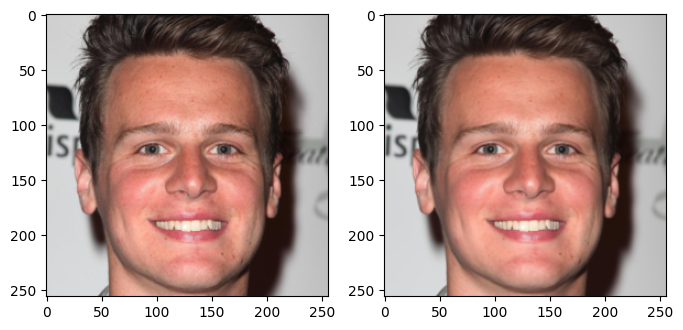

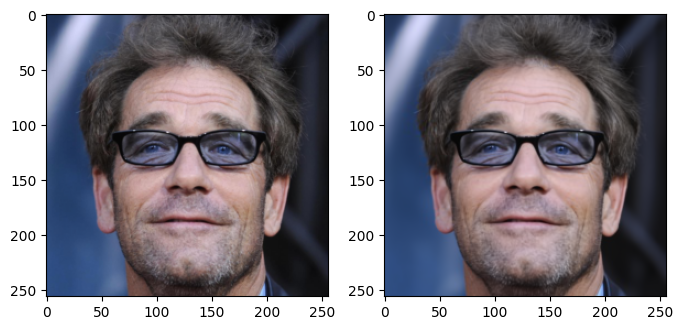

In [8]:
cond_bg = encoder.encode(batch_bg.to(device))
cond_t = encoder.encode(batch_t.to(device))
xT_bg = encoder.encode_stochastic(batch_bg.to(device), cond_bg, T=250)
xT_t = encoder.encode_stochastic(batch_t.to(device), cond_t, T=250)

show_results_bg_t(encoder, batch_bg, batch_t, xT_bg, xT_t, cond_bg, cond_t)

## Reconstruction by MLP (learn from diffusion AE)

In [24]:
mlp_model.denormalize()

TypeError: MlpModel.denormalize() missing 1 required positional argument: 'cond'

In [ ]:

# mlp_conf = Namespace(**load_yaml_config("./results/baseline/znorm_lr1e-2/logs/version_0/hparams.yaml"))

load_conf = ffhq256_autoenc_mlp()


result_path = "./results/baseline/znorm/mlp-epoch=449.ckpt" 

mlp_model, mlp_model_ema = load_cs_mlp(load_conf, result_path)
mlp_model.eval()
mlp_model.to(device)
# mlp_model_ema.eval()b
# mlp_model_ema.to(device)
    

Seed set to 0
Seed set to 0


Model params: 160.69 M
loading pretrain ... 130M
step: 1563562
loading latent stats ...
Loaded pretrained model from checkpoints/ffhq256_autoenc/last.ckpt' successfully.
load weights from ./results/baseline/znorm/mlp-epoch=449.ckpt
latent step: 562500


MlpModel(
  (discriminator): Discriminator(
    (model): Sequential(
      (0): Linear(in_features=512, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (model): LitModel(
    (model): BeatGANsAutoencModel(
      (time_embed): TimeStyleSeperateEmbed(
        (time_embed): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): SiLU()
          (2): Linear(in_features=512, out_features=512, bias=True)
        )
        (style): Identity()
      )
      (input_blocks): ModuleList(
        (0): TimestepEmbedSequential(
          (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (1-2): 2 x TimestepEmbedSequential(
          (0): ResBlock(
            (in_layers): Sequential(
        

In [22]:
load_conf.manipulate_znormalize = True
with torch.no_grad():
    c_bg, s_bg = mlp_model.ema_mlp(cond_bg)  # For EMA MLP
    c_t, s_t = mlp_model.ema_mlp(cond_t)  # For EMA MLP
    
    if load_conf.manipulate_znormalize:
        latent_bg = mlp_model.denormalize(c_bg)
        latent_t = mlp_model.denormalize(c_t + s_t)
        latent_swap_bg =  mlp_model.denormalize(c_bg + s_t)
        latent_swap_t =  mlp_model.denormalize(c_t)
    else:
        latent_bg = c_bg
        latent_t  = c_t + s_t       
        latent_swap_bg =  c_bg + s_t
        latent_swap_t =  c_t
        
    # xT_bg = encoder.encode_stochastic(batch_bg.to(device), cond_bg, T=250)
    # xT_t = encoder.encode_stochastic(batch_t.to(device), cond_t, T=250)

    show_results_bg_t(encoder, batch_bg, batch_t, xT_bg, xT_t, latent_bg, latent_t)

AttributeError: 'NoneType' object has no attribute 'to'

denormalize(c_bg) = c_bg * std + mean
denormalize(c_t + s_t) = (c_t + s_t) * std + mean 
                    = c_t * std + s_t * std + mean


denormalize(c_bg + s_t) = c_bg 

In [ ]:
## c_bg + s_bg for background 
with torch.no_grad():
    norm_cond_bg = cond_bg
    norm_cond_t = cond_t
    
    c_bg, s_bg = mlp_model.ema_mlp(norm_cond_bg)  # For EMA MLP
    c_t, s_t = mlp_model.ema_mlp(norm_cond_t)  # For EMA MLP
    
    new_cond_bg = mlp_conf.c_lambda*c_bg + mlp_conf.s_lambda*s_t
    new_cond_t = mlp_conf.c_lambda*c_t

new_xT_bg = model.encode_stochastic(batch_bg.to(device), mlp_conf.c_lambda*c_bg, T=250)
new_xT_t = model.encode_stochastic(batch_t.to(device),  mlp_conf.c_lambda*c_t+ mlp_conf.s_lambda*s_t, T=250)
show_results_bg_t(model, batch_bg, batch_t, xT_bg, xT_t, new_cond_bg, new_cond_t)   
#     # OR

AttributeError: 'MappingNetwork_cs' object has no attribute 'conf'

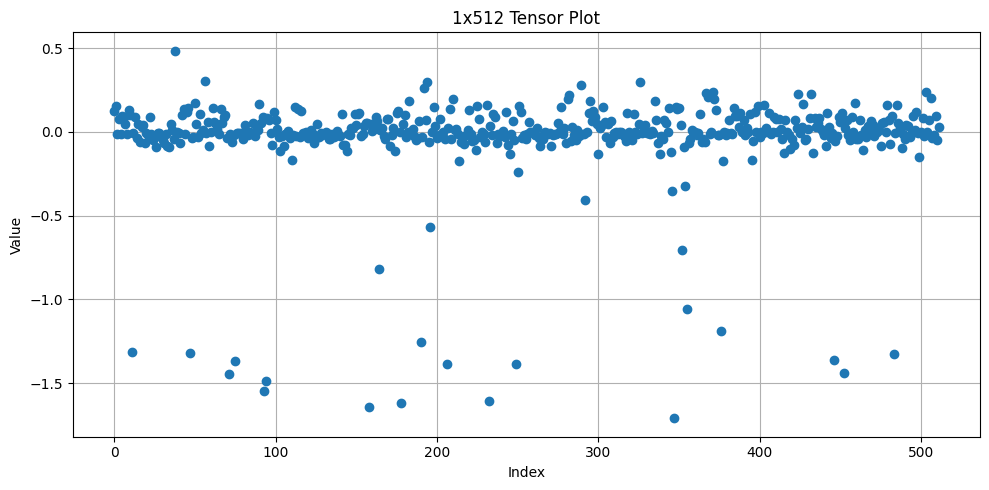

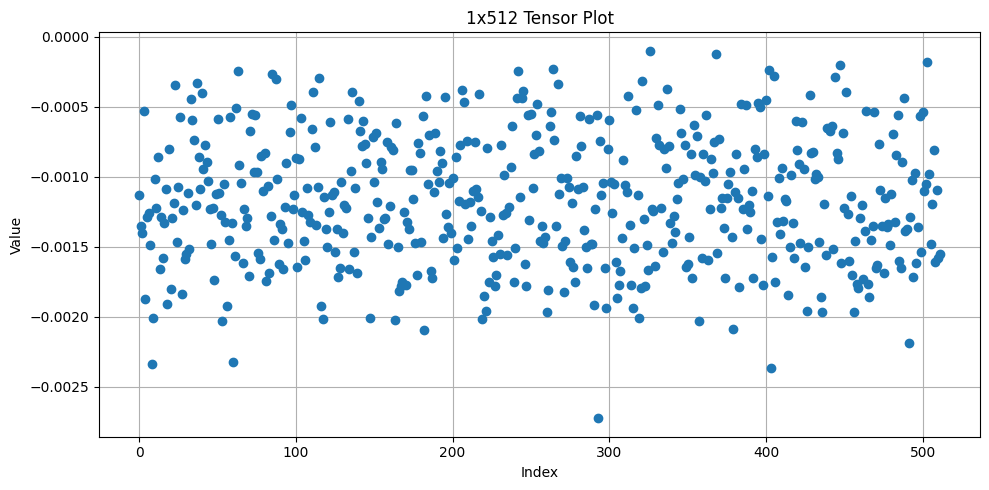

In [ ]:

# # Create a 1x512 tensor
# s_bg_norm = 0.4* math.sqrt(512) * F.normalize(cls_model.classifier.weight[cls_id][None, :], dim=1)
tensor = mlp_conf.c_lambda*c_bg.cpu().detach()  # Random values for demonstration

# Convert tensor to numpy for plotting
vector = tensor.flatten()

# Create x-axis indices
x_indices = np.arange(vector.shape[0])

# Plot the tensor
plt.figure(figsize=(10, 5))
plt.plot(x_indices, vector, marker='o', linestyle='', linewidth=1)
plt.title("1x512 Tensor Plot")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

# # Create a 1x512 tensor
# s_bg_norm = 0.4* math.sqrt(512) * F.normalize(cls_model.classifier.weight[cls_id][None, :], dim=1)
tensor = mlp_conf.s_lambda*s_bg.cpu().detach()  # Random values for demonstration

# Convert tensor to numpy for plotting
vector = tensor.flatten()

# Create x-axis indices
x_indices = np.arange(vector.shape[0])

# Plot the tensor
plt.figure(figsize=(10, 5))
plt.plot(x_indices, vector, marker='o', linestyle='', linewidth=1)
plt.title("1x512 Tensor Plot")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()